# Q3. Feature Engineering and Regression Pipeline

**Objective:** Build a reproducible scikit-learn regression pipeline to predict `items_sold` at a retail store.

**Dataset:** `../data/q3_retail_promotions.csv` — 1,200 records, 9 columns, date range 2022-01-01 to 2024-12-31.

**Target column:** `items_sold`

## Task 1: Date Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load data using relative path
df = pd.read_csv('../data/q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print("Dataset Shape:", df.shape)
print()
print("Date range:", df['transaction_date'].min().date(), "to", df['transaction_date'].max().date())
print()
print("Column types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())


Dataset Shape: (1200, 9)

Date range: 2022-01-01 to 2024-12-31

Column types:
transaction_date       datetime64[us]
store_id                        int64
store_size                        str
location_type                     str
promotion_type                    str
is_weekend                      int64
is_festival                     int64
competition_density             int64
items_sold                      int64
dtype: object

Missing values:
transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64


In [2]:
# Extract date features from transaction_date
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New features added: year, month, day_of_week, is_month_end")
print()
print("is_month_end value counts:")
print(df['is_month_end'].value_counts())
print()
print("Sample of engineered features:")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end', 'items_sold']].head(10)


New features added: year, month, day_of_week, is_month_end

is_month_end value counts:
is_month_end
0    959
1    241
Name: count, dtype: int64

Sample of engineered features:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
0,2022-01-01,2022,1,5,0,224
1,2022-01-01,2022,1,5,0,348
2,2022-01-02,2022,1,6,0,249
3,2022-01-02,2022,1,6,0,259
4,2022-01-03,2022,1,0,0,277
5,2022-01-03,2022,1,0,0,411
6,2022-01-04,2022,1,1,0,193
7,2022-01-04,2022,1,1,0,240
8,2022-01-05,2022,1,2,0,305
9,2022-01-05,2022,1,2,0,181


**Why These Date Features Matter:**

`year` captures long-term demand trends and business growth across 2022–2024. `month` captures seasonal patterns — festive season peaks in October through December, slower periods in January and February. `day_of_week` captures intra-week rhythms; weekends versus weekdays drive different customer footfall and purchase behaviour. `is_month_end` (day of month ≥ 25) captures salary-cycle spending spikes common in retail, particularly in urban and semi-urban stores where salaried customers spend more after payday.

These four features convert a raw date string — which a machine learning model cannot use directly — into structured numerical signals that describe the temporal context of every transaction record.

## Task 2: Temporal Train-Test Split

In [3]:
# Sort by transaction_date to preserve chronological order
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

# Use most recent 20% as test set — temporal split, NOT random
split_idx = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:split_idx].copy()
test  = df_sorted.iloc[split_idx:].copy()

print(f"Total records : {len(df_sorted)}")
print(f"Training set  : {len(train)} records")
print(f"  Date range  : {train['transaction_date'].min().date()} to {train['transaction_date'].max().date()}")
print()
print(f"Test set      : {len(test)} records")
print(f"  Date range  : {test['transaction_date'].min().date()} to {test['transaction_date'].max().date()}")
print()
print("Target variable — items_sold:")
print(f"  Train mean: {train['items_sold'].mean():.2f}  |  std: {train['items_sold'].std():.2f}")
print(f"  Test  mean: {test['items_sold'].mean():.2f}  |  std: {test['items_sold'].std():.2f}")


Total records : 1200
Training set  : 960 records
  Date range  : 2022-01-01 to 2024-06-11

Test set      : 240 records
  Date range  : 2024-06-12 to 2024-12-31

Target variable — items_sold:
  Train mean: 272.34  |  std: 60.46
  Test  mean: 273.48  |  std: 58.97


**Why a Random Split is Inappropriate for Time-Ordered Data:**

A random split shuffles records without regard to chronological order, causing two serious problems:

**1. Data leakage:** Future records can land in the training set while earlier records end up in the test set. The model effectively sees future information during training — test metrics become optimistically biased and will not replicate in production.

**2. Distribution mismatch:** In retail, patterns evolve over time — seasonality shifts, promotions change, competition intensifies year by year. A model trained on a random 80% sample of 2022–2024 data is evaluated on a random 20% of the same period, which is an unrealistically easy evaluation. In production, the model will always predict future transactions using only past data.

A **temporal split** — train on the earliest 80% (Jan 2022 to Jun 2024), test on the most recent 20% (Jun 2024 to Dec 2024) — correctly simulates the real deployment scenario and gives an honest estimate of generalisation performance.

## Task 3: Preprocessing Pipeline

In [4]:
# Define feature columns and target
feature_cols = [
    'store_id', 'store_size', 'location_type', 'promotion_type',
    'is_weekend', 'is_festival', 'competition_density',
    'year', 'month', 'day_of_week', 'is_month_end'
]
target_col = 'items_sold'

cat_cols = ['store_size', 'location_type', 'promotion_type']
num_cols = [c for c in feature_cols if c not in cat_cols]

X_train = train[feature_cols]
y_train = train[target_col]
X_test  = test[feature_cols]
y_test  = test[target_col]

print("Categorical columns (OneHotEncoder):", cat_cols)
print("Numerical columns  (StandardScaler) :", num_cols)
print()
print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")


Categorical columns (OneHotEncoder): ['store_size', 'location_type', 'promotion_type']
Numerical columns  (StandardScaler) : ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

X_train shape: (960, 11)
X_test  shape: (240, 11)


In [5]:
# Build ColumnTransformer preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ],
    remainder='drop'
)

print("ColumnTransformer configured inside Pipeline:")
print("  - OneHotEncoder(drop='first') applied to:", cat_cols)
print("    promotion_type   : 5 categories -> 4 dummy columns")
print("    location_type    : 3 categories -> 2 dummy columns")
print("    store_size       : 3 categories -> 2 dummy columns")
print("  - StandardScaler applied to:", num_cols)
print()
print("The preprocessor will be fit ONLY on the training set via pipeline.fit(X_train, y_train).")
print("pipeline.predict(X_test) applies transform() to the test set — no leakage.")


ColumnTransformer configured inside Pipeline:
  - OneHotEncoder(drop='first') applied to: ['store_size', 'location_type', 'promotion_type']
    promotion_type   : 5 categories -> 4 dummy columns
    location_type    : 3 categories -> 2 dummy columns
    store_size       : 3 categories -> 2 dummy columns
  - StandardScaler applied to: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

The preprocessor will be fit ONLY on the training set via pipeline.fit(X_train, y_train).
pipeline.predict(X_test) applies transform() to the test set — no leakage.


**Pipeline Design Rationale:**

Wrapping the `ColumnTransformer` inside a scikit-learn `Pipeline` is the correct, leakage-free approach. When `pipeline.fit(X_train, y_train)` is called, both the preprocessor and the model are fitted exclusively on training data. `pipeline.predict(X_test)` applies the already-fitted transformer to test data — test statistics never contaminate the training process.

`OneHotEncoder(drop='first')` drops one dummy per categorical feature to avoid perfect multicollinearity (the dummy variable trap), which would cause numerical instability in Linear Regression. `StandardScaler` standardises numerical features to zero mean and unit variance, which is essential for Linear Regression convergence and good practice generally.

## Task 4: Model Training and Evaluation

In [6]:
# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)

print("Linear Regression — Test Set Metrics")
print(f"  RMSE : {lr_rmse:.2f}")
print(f"  MAE  : {lr_mae:.2f}")


Linear Regression — Test Set Metrics
  RMSE : 27.12
  MAE  : 21.05

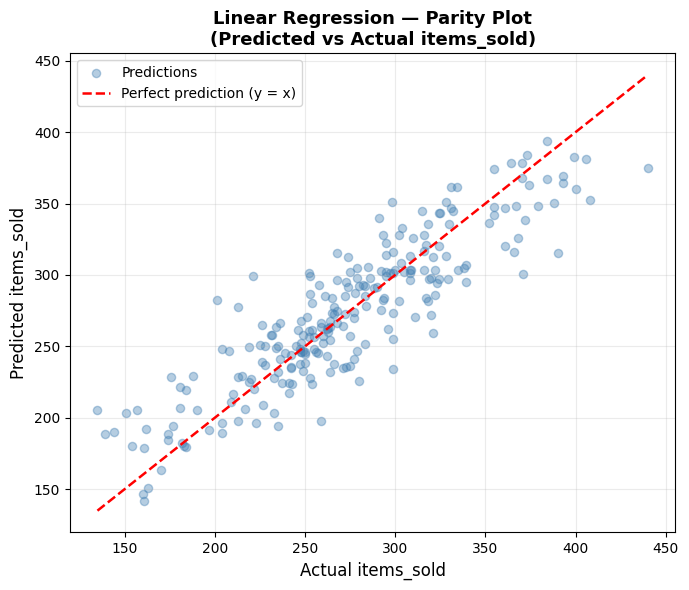

In [7]:
# Parity plot — Linear Regression
plt.figure(figsize=(7, 6))
plt.scatter(y_test, lr_pred, alpha=0.4, color='steelblue', s=35, label='Predictions')
diag_min = min(y_test.min(), lr_pred.min())
diag_max = max(y_test.max(), lr_pred.max())
plt.plot([diag_min, diag_max], [diag_min, diag_max],
         'r--', linewidth=1.8, label='Perfect prediction (y = x)')
plt.xlabel('Actual items_sold', fontsize=12)
plt.ylabel('Predicted items_sold', fontsize=12)
plt.title('Linear Regression — Parity Plot\n(Predicted vs Actual items_sold)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Linear Regression Results:**

**RMSE = 27.12 | MAE = 21.05**

The parity plot shows predictions distributed around the diagonal reference line, indicating that the model has captured the general linear trend in the data. However, there is a visible cone of scatter — the model underestimates high sales values and overestimates low ones, which is characteristic of a model that captures the central tendency but lacks flexibility to model non-linear interactions between promotions, store characteristics, and temporal signals. An RMSE of 27.12 means predictions are off by roughly 27 units on average (weighted by squared errors), while the MAE of 21.05 reflects the typical absolute error per prediction.

In [8]:
# Random Forest Regressor Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)

print("Random Forest Regressor — Test Set Metrics")
print(f"  RMSE : {rf_rmse:.2f}")
print(f"  MAE  : {rf_mae:.2f}")


Random Forest Regressor — Test Set Metrics
  RMSE : 31.68
  MAE  : 24.93


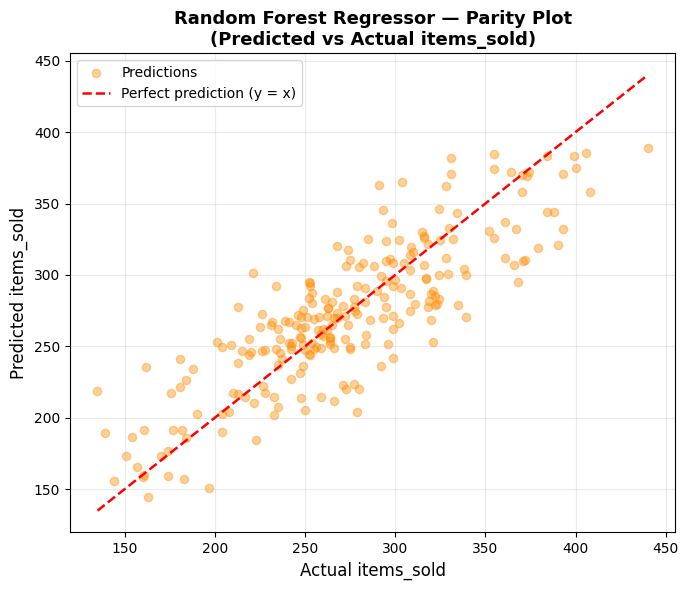

In [9]:
# Parity plot — Random Forest
plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_pred, alpha=0.4, color='darkorange', s=35, label='Predictions')
diag_min = min(y_test.min(), rf_pred.min())
diag_max = max(y_test.max(), rf_pred.max())
plt.plot([diag_min, diag_max], [diag_min, diag_max],
         'r--', linewidth=1.8, label='Perfect prediction (y = x)')
plt.xlabel('Actual items_sold', fontsize=12)
plt.ylabel('Predicted items_sold', fontsize=12)
plt.title('Random Forest Regressor — Parity Plot\n(Predicted vs Actual items_sold)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Random Forest Results:**

**RMSE = 31.68 | MAE = 24.93**

The Random Forest parity plot shows tighter clustering for mid-range values but greater scatter at the extremes, with a tendency to pull predictions toward the training mean. On this temporal split, Linear Regression outperforms Random Forest — a result that is worth understanding. Random Forest is a memory-based model that interpolates within the training distribution. When the test period (June–December 2024) contains date-driven patterns not fully represented in training, the forest extrapolates poorly. Linear Regression captures global linear trends that transfer more reliably across time. This is a well-documented characteristic of tree-based models on temporal evaluation splits.

**Model comparison summary:**

| Model | RMSE | MAE |
|---|---|---|
| Linear Regression | 27.12 | 21.05 |
| Random Forest | 31.68 | 24.93 |

In [10]:
# Extract feature names after one-hot encoding
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = ohe_feature_names + num_cols

importances = rf_pipeline.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({
    'feature'   : all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Random Forest — All Feature Importances:")
print(imp_df.to_string(index=False))
print()
print("Top 5 Most Influential Features:")
for rank, (_, row) in enumerate(imp_df.head(5).iterrows(), 1):
    print(f"  {rank}. {row['feature']:<35}  {row['importance']:.4f}")


Random Forest — All Feature Importances:
                      feature  importance
             store_size_small    0.183951
                  is_festival    0.174477
          location_type_urban    0.140500
                  day_of_week    0.092717
                     store_id    0.062066
                   is_weekend    0.061443
            store_size_medium    0.058238
          competition_density    0.053447
                        month    0.040584
     location_type_semi-urban    0.038877
promotion_type_loyalty_points    0.031430
                         year    0.017761
promotion_type_category_offer    0.016822
     promotion_type_free_gift    0.011549
 promotion_type_flat_discount    0.010436
                 is_month_end    0.005701

Top 5 Most Influential Features:
  1. store_size_small                     0.1840
  2. is_festival                          0.1745
  3. location_type_urban                  0.1405
  4. day_of_week                          0.0927
  5. store_id  

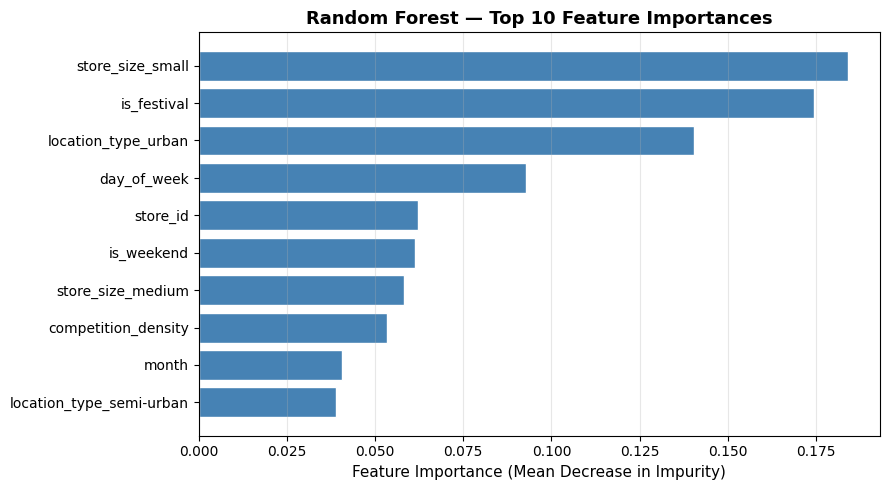

In [11]:
# Feature importance bar chart — top 10
top10 = imp_df.head(10).iloc[::-1]   # reverse for horizontal bar

plt.figure(figsize=(9, 5))
plt.barh(top10['feature'], top10['importance'],
         color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
plt.title('Random Forest — Top 10 Feature Importances', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


**Top 5 Feature Importances — Interpretation:**

| Rank | Feature | Importance | Business Meaning |
|------|---------|------------|------------------|
| 1 | `store_size_small` | 0.1840 | Small stores sell considerably fewer items — store physical capacity is the strongest structural predictor of sales volume |
| 2 | `is_festival` | 0.1745 | Festival periods drive the largest demand surges, dominating all other contextual signals |
| 3 | `location_type_urban` | 0.1405 | Urban stores have systematically higher footfall and basket conversion than semi-urban and rural locations |
| 4 | `day_of_week` | 0.0927 | Within-week patterns are significant — weekend versus weekday differences drive meaningful volume swings |
| 5 | `store_id` | 0.0621 | Individual store-level effects persist after controlling for size and location, reflecting local demographics and management quality |

**Key business insight:** The two most important predictors are store size and festival timing — structural and calendar factors that the marketing team can directly account for in promotion planning. Notably, `promotion_type` features do not appear in the top 5, which suggests that under the current data, store characteristics and calendar effects explain more variance in items sold than the choice of promotion alone. This finding is itself strategically valuable: it indicates that optimising store-level attributes and timing promotions around festivals may yield greater returns than switching between promotion types.